# Solar Filament Segmentation 2026 — Exploratory Data Analysis

**Competition task:** instance segmentation of thin, elongated, often-branching dark
filament structures in 2048x2048 grayscale H-alpha solar images (MAGFiLO 1.0 dataset,
707 train / 180 test images, GONG observatory network). Each filament gets its own
predicted mask; submissions are scored on **Panoptic Quality (PQ)** plus mean **Dice**,
which means instance separation (not just per-pixel accuracy) directly determines the
score.

**What this notebook covers:** a single, coherent, re-runnable pass over the dataset —
image-level statistics, annotation-level statistics, mask/RLE round-trip integrity,
illustrative visual examples, and cross-referencing/data-quality/edge-case checks —
followed by a synthesis of concrete pipeline-design implications. It consolidates and
re-executes (live, from the raw files on disk) the analysis originally split across five
parallel EDA passes, whose standalone scripts/artifacts live under
`notebooks/eda_assets/scripts/` and `notebooks/eda_assets/*.csv` / `*.png` — this
notebook reproduces their key numbers and plots directly from code rather than just
embedding those pre-saved images, so it stays correct if the underlying data changes.

**Runtime note:** most sections run over the full dataset (all 887 images, all 8199
annotations). Two of the more expensive per-annotation image-decoding steps (the
inside-vs-outside intensity check and the visual sample grid) use a representative
subsample rather than every annotation/image, so the whole notebook finishes in a few
minutes — this is called out explicitly where it happens, with the full-pass numbers
from the original EDA agents quoted alongside for reference.

In [1]:
%matplotlib inline
import json, os, re, time
from pathlib import Path
from datetime import datetime
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.lines import Line2D
from PIL import Image
import cv2
from pycocotools import mask as maskUtils
from shapely.geometry import LinearRing

plt.rcParams["figure.facecolor"] = "white"
pd.set_option("display.max_columns", 20)
RNG = np.random.default_rng(42)

REPO_ROOT = Path("D:/SolarSeg")
DATA_ROOT = REPO_ROOT / "data" / "MAGFiLO_1.0_Kaggle_2026"
TRAIN_IMG_DIR = DATA_ROOT / "train" / "train_images"
TEST_IMG_DIR = DATA_ROOT / "test" / "test_images"
ANN_JSON_PATH = DATA_ROOT / "train" / "MAGFiLO_1.0_Annotations_kaggle2026_train.json"

t0 = time.time()
with open(ANN_JSON_PATH, "r", encoding="utf-8") as f:
    coco = json.load(f)

images = coco["images"]
annotations = coco["annotations"]
categories = coco["categories"]
licenses_field = coco["licenses"]

images_by_id = {im["id"]: im for im in images}
anns_by_id = {a["id"]: a for a in annotations}
anns_by_image = defaultdict(list)
for a in annotations:
    anns_by_image[a["image_id"]].append(a)

print(f"Loaded COCO annotation JSON in {time.time()-t0:.1f}s")
print(f"images[] entries: {len(images)}   annotations: {len(annotations)}   categories: {len(categories)}")
print(f"train_images/ on disk: {len(os.listdir(TRAIN_IMG_DIR))}   test_images/ on disk: {len(os.listdir(TEST_IMG_DIR))}")

Loaded COCO annotation JSON in 0.2s
images[] entries: 1154   annotations: 8199   categories: 4
train_images/ on disk: 707   test_images/ on disk: 180


## 1. Image-level statistics

We scan every image in both `train_images/` (707 files) and `test_images/` (180 files)
directly off disk: dimensions, color mode, file size, pixel-intensity summary stats, and
the instrument code + capture timestamp parsed out of the filename
(`YYYYMMDDHHMMSSII.jpeg`).

In [2]:
FNAME_RE = re.compile(r"^(\d{14})([A-Za-z]{2})\.jpe?g$", re.IGNORECASE)

def parse_filename(fname):
    m = FNAME_RE.match(fname)
    if not m:
        return None, None, False
    ts_str, code_ = m.group(1), m.group(2)
    try:
        dt = datetime.strptime(ts_str, "%Y%m%d%H%M%S")
    except ValueError:
        return None, code_, False
    return dt, code_, True

def scan_dir(dir_path, split_label):
    rows = []
    files = sorted(f for f in os.listdir(dir_path) if f.lower().endswith((".jpg", ".jpeg")))
    for fname in files:
        fpath = dir_path / fname
        with Image.open(fpath) as im:
            width, height = im.size
            mode = im.mode
            arr = np.asarray(im)
        dt, instrument_code, parse_ok = parse_filename(fname)
        rows.append(dict(
            file_name=fname, split=split_label, width=width, height=height, mode=mode,
            n_channels=(1 if arr.ndim == 2 else arr.shape[2]),
            file_size_bytes=fpath.stat().st_size,
            px_mean=float(arr.mean()), px_std=float(arr.std()),
            px_min=float(arr.min()), px_max=float(arr.max()),
            filename_parse_ok=parse_ok, capture_datetime=dt, instrument_code=instrument_code,
        ))
    return rows

t0 = time.time()
img_rows = scan_dir(TRAIN_IMG_DIR, "train") + scan_dir(TEST_IMG_DIR, "test")
df_img = pd.DataFrame(img_rows)
df_img["capture_datetime"] = pd.to_datetime(df_img["capture_datetime"])
print(f"Scanned {len(df_img)} images (train+test) from disk in {time.time()-t0:.1f}s")
df_img.head(3)

Scanned 887 images (train+test) from disk in 20.7s


,file_name,split,width,height,mode,n_channels,file_size_bytes,px_mean,px_std,px_min,px_max,filename_parse_ok,capture_datetime,instrument_code
0,20110109104734Ch.jpeg,train,2048,2048,L,1,873742,85.329510,57.091923,0.0,230.0,True,2011-01-09 10:47:34,Ch
1,20110114105034Ch.jpeg,train,2048,2048,L,1,870883,83.648211,57.631484,0.0,231.0,True,2011-01-14 10:50:34,Ch
2,20110119082634Lh.jpeg,train,2048,2048,L,1,748571,80.965201,58.915110,0.0,242.0,True,2011-01-19 08:26:34,Lh


In [3]:
expected_w, expected_h, expected_mode = 2048, 2048, "L"
df_img["is_expected_dim"] = (df_img.width == expected_w) & (df_img.height == expected_h)
df_img["is_expected_mode"] = df_img["mode"] == expected_mode

n_bad_dim = int((~df_img.is_expected_dim).sum())
n_bad_mode = int((~df_img.is_expected_mode).sum())
n_bad_parse = int((~df_img.filename_parse_ok).sum())
overlap = set(df_img[df_img.split == "train"].file_name) & set(df_img[df_img.split == "test"].file_name)

print(f"Images NOT {expected_w}x{expected_h}: {n_bad_dim} / {len(df_img)}")
print(f"Images NOT mode '{expected_mode}': {n_bad_mode} / {len(df_img)}")
print(f"Filename parse failures: {n_bad_parse} / {len(df_img)}")
print(f"train/test filename overlap: {len(overlap)}")

df_img.groupby("split").agg(
    n=("file_name", "count"), n_2048x2048=("is_expected_dim", "sum"),
    n_mode_L=("is_expected_mode", "sum"), n_filename_parsed=("filename_parse_ok", "sum"),
)

Images NOT 2048x2048: 0 / 887
Images NOT mode 'L': 0 / 887
Filename parse failures: 0 / 887
train/test filename overlap: 0


,n,n_2048x2048,n_mode_L,n_filename_parsed
split,,,,
test,180,180,180,180
train,707,707,707,707


instrument codes in train: ['Bh', 'Ch', 'Lh', 'Mh', 'Th', 'Uh']
instrument codes in test:  ['Bh', 'Ch', 'Lh', 'Mh', 'Th', 'Uh']
codes in test but not train: set()   codes in train but not test: set()


split,test,train,train_frac,test_frac
instrument_code,,,,
Lh,34,127,0.179632,0.188889
Ch,33,125,0.176803,0.183333
Mh,26,125,0.176803,0.144444
Bh,33,118,0.166902,0.183333
Th,27,110,0.155587,0.150000
Uh,27,102,0.144272,0.150000


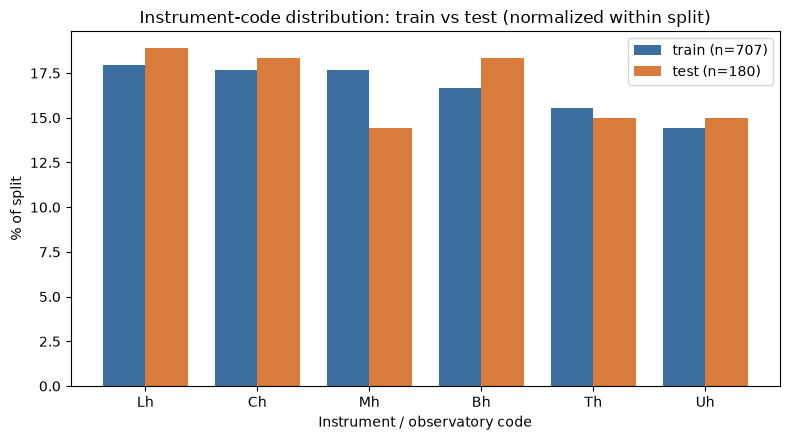

In [4]:
inst_counts = df_img.groupby(["split", "instrument_code"]).size().rename("count").reset_index()
inst_pivot = inst_counts.pivot(index="instrument_code", columns="split", values="count").fillna(0)
inst_pivot["train_frac"] = inst_pivot["train"] / inst_pivot["train"].sum()
inst_pivot["test_frac"] = inst_pivot["test"] / inst_pivot["test"].sum()
inst_pivot = inst_pivot.sort_values("train", ascending=False)

codes_train = set(df_img[df_img.split == "train"].instrument_code.dropna().unique())
codes_test = set(df_img[df_img.split == "test"].instrument_code.dropna().unique())
print(f"instrument codes in train: {sorted(codes_train)}")
print(f"instrument codes in test:  {sorted(codes_test)}")
print(f"codes in test but not train: {codes_test - codes_train}   codes in train but not test: {codes_train - codes_test}")
display(inst_pivot)

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(inst_pivot)); w = 0.38
ax.bar(x - w/2, inst_pivot.train_frac * 100, w, label=f"train (n={int(inst_pivot.train.sum())})", color="#3b6fa0")
ax.bar(x + w/2, inst_pivot.test_frac * 100, w, label=f"test (n={int(inst_pivot.test.sum())})", color="#d97c3b")
ax.set_xticks(x); ax.set_xticklabels(inst_pivot.index)
ax.set_xlabel("Instrument / observatory code"); ax.set_ylabel("% of split")
ax.set_title("Instrument-code distribution: train vs test (normalized within split)")
ax.legend()
plt.tight_layout(); plt.show()

train capture-date range: 2011-01-09 10:47:34 to 2022-08-03 07:47:52  (n=707)
test  capture-date range: 2011-01-20 10:55:34 to 2022-07-28 18:53:52  (n=180)


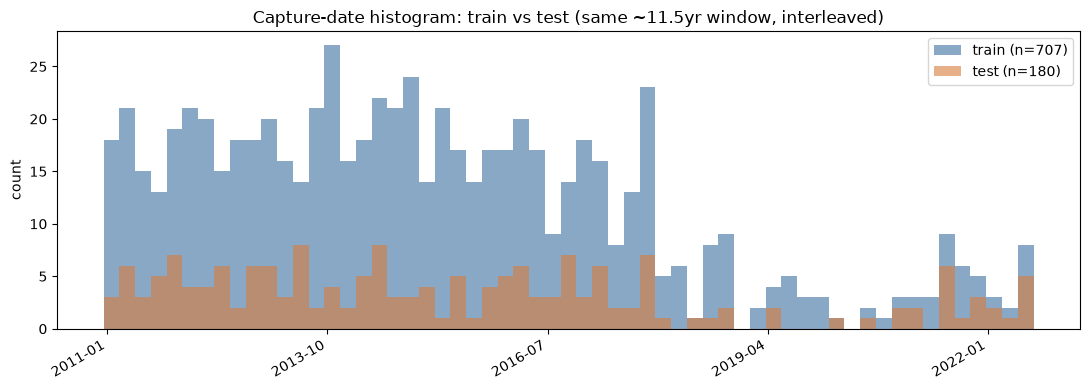

In [5]:
df_dt = df_img.dropna(subset=["capture_datetime"])
train_dt = df_dt[df_dt.split == "train"].capture_datetime
test_dt = df_dt[df_dt.split == "test"].capture_datetime
print(f"train capture-date range: {train_dt.min()} to {train_dt.max()}  (n={len(train_dt)})")
print(f"test  capture-date range: {test_dt.min()} to {test_dt.max()}  (n={len(test_dt)})")

fig, ax = plt.subplots(figsize=(11, 4))
bins = np.linspace(mdates.date2num(df_dt.capture_datetime.min()), mdates.date2num(df_dt.capture_datetime.max()), 60)
ax.hist(mdates.date2num(train_dt), bins=bins, alpha=0.6, label=f"train (n={len(train_dt)})", color="#3b6fa0")
ax.hist(mdates.date2num(test_dt), bins=bins, alpha=0.6, label=f"test (n={len(test_dt)})", color="#d97c3b")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.set_ylabel("count"); ax.set_title("Capture-date histogram: train vs test (same ~11.5yr window, interleaved)")
ax.legend(); fig.autofmt_xdate(); plt.tight_layout(); plt.show()

Pooled pixel subsample from 60 imgs/split in 1.9s (12000000 train px, 12000000 test px)


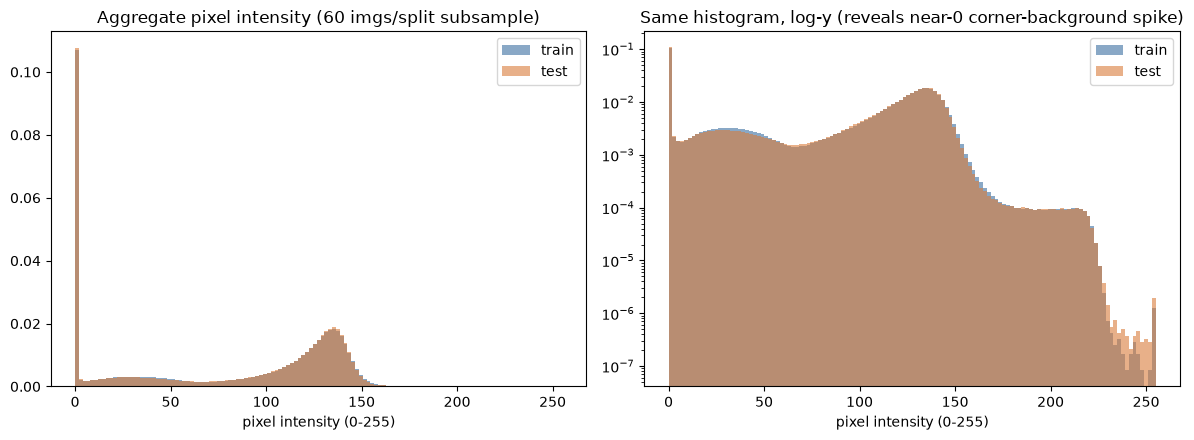

train px_mean overall: 83.39 +/- 3.16
test  px_mean overall: 83.91 +/- 3.56


In [6]:
N_SAMPLE_PER_SPLIT = 60  # subsample for the aggregate pixel histogram, not the per-image stats above

def sample_pixel_values(split_df, split_dir, n_sample):
    chosen = split_df.sample(n=min(n_sample, len(split_df)), random_state=42)
    vals = []
    for fname in chosen.file_name:
        with Image.open(split_dir / fname) as im:
            arr = np.asarray(im).reshape(-1)
        if arr.size > 200_000:
            arr = arr[RNG.choice(arr.size, size=200_000, replace=False)]
        vals.append(arr)
    return np.concatenate(vals)

t0 = time.time()
train_px = sample_pixel_values(df_img[df_img.split == "train"], TRAIN_IMG_DIR, N_SAMPLE_PER_SPLIT)
test_px = sample_pixel_values(df_img[df_img.split == "test"], TEST_IMG_DIR, N_SAMPLE_PER_SPLIT)
print(f"Pooled pixel subsample from {N_SAMPLE_PER_SPLIT} imgs/split in {time.time()-t0:.1f}s "
      f"({len(train_px)} train px, {len(test_px)} test px)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
bins = np.linspace(0, 255, 128)
for ax, yscale, title in zip(axes, ["linear", "log"],
                              [f"Aggregate pixel intensity ({N_SAMPLE_PER_SPLIT} imgs/split subsample)",
                               "Same histogram, log-y (reveals near-0 corner-background spike)"]):
    ax.hist(train_px, bins=bins, alpha=0.6, density=True, label="train", color="#3b6fa0")
    ax.hist(test_px, bins=bins, alpha=0.6, density=True, label="test", color="#d97c3b")
    ax.set_yscale(yscale); ax.set_xlabel("pixel intensity (0-255)"); ax.set_title(title); ax.legend()
plt.tight_layout(); plt.show()

print(f"train px_mean overall: {df_img[df_img.split=='train'].px_mean.mean():.2f} +/- {df_img[df_img.split=='train'].px_mean.std():.2f}")
print(f"test  px_mean overall: {df_img[df_img.split=='test'].px_mean.mean():.2f} +/- {df_img[df_img.split=='test'].px_mean.std():.2f}")

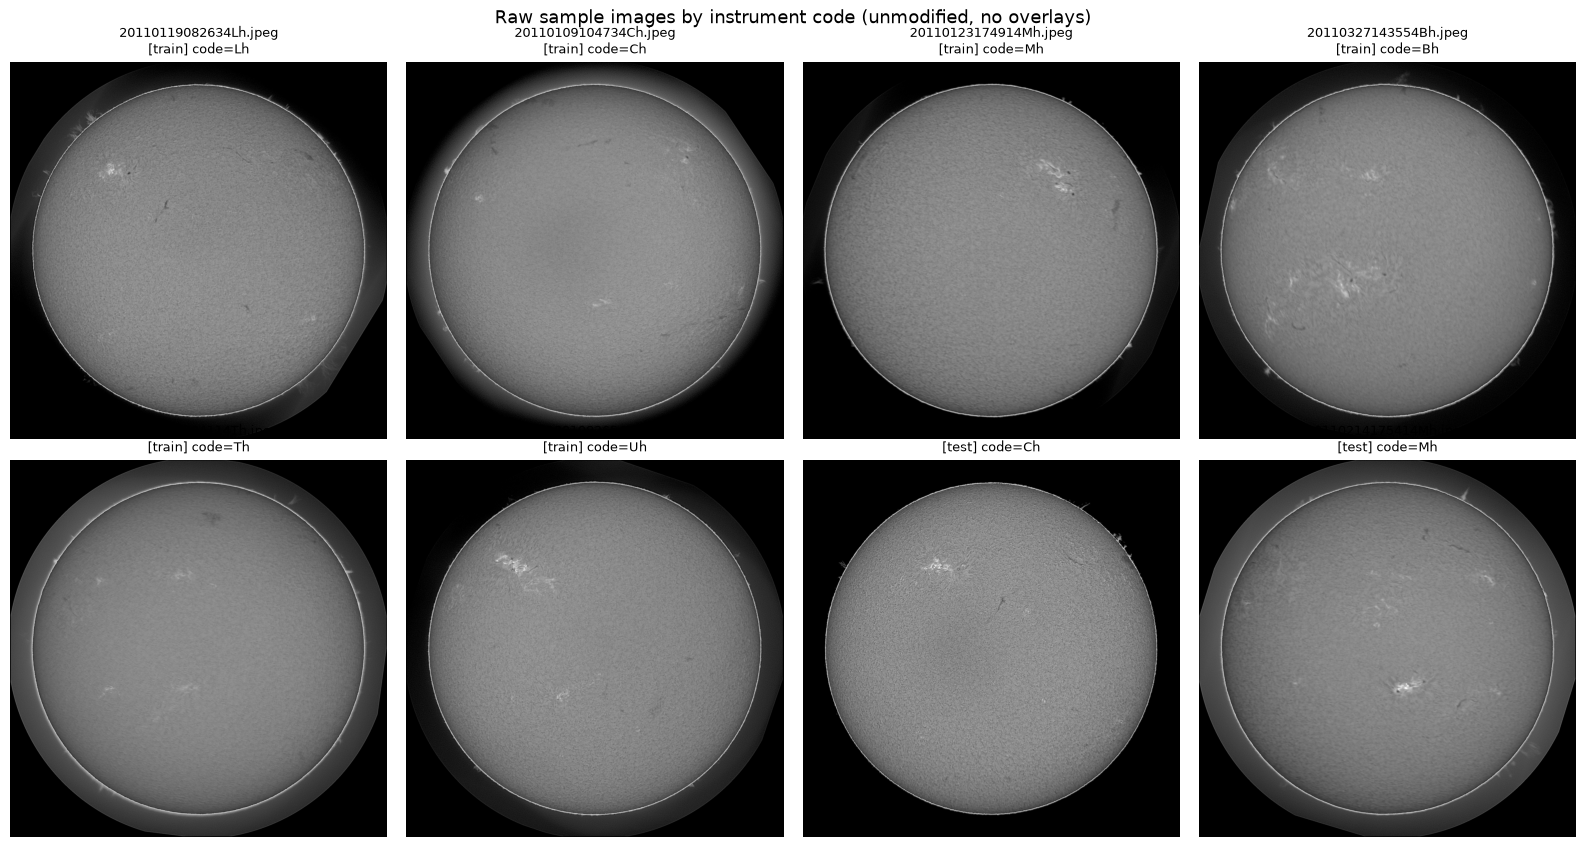

In [7]:
# One raw (unmodified) sample image per instrument code (6 train) + 2 test images
codes_by_count = inst_pivot.sort_values("train", ascending=False).index.tolist()
sample_rows = []
for c in codes_by_count:
    cand = df_img[(df_img.split == "train") & (df_img.instrument_code == c)]
    if len(cand):
        sample_rows.append(cand.iloc[0])
    if len(sample_rows) >= 6:
        break
test_codes_used = set()
for _, r in df_img[df_img.split == "test"].iterrows():
    if r.instrument_code not in test_codes_used:
        sample_rows.append(r); test_codes_used.add(r.instrument_code)
    if len(test_codes_used) >= 2:
        break

fig, axes = plt.subplots(2, 4, figsize=(16, 8.6))
axes = axes.flatten()
for ax in axes:
    ax.axis("off")
for ax, row in zip(axes, sample_rows):
    d = TRAIN_IMG_DIR if row.split == "train" else TEST_IMG_DIR
    with Image.open(d / row.file_name) as im:
        arr = np.asarray(im)
    ax.imshow(arr, cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"{row.file_name}\n[{row.split}] code={row.instrument_code}", fontsize=9)
    ax.axis("off")
fig.suptitle("Raw sample images by instrument code (unmodified, no overlays)", fontsize=13)
plt.tight_layout(); plt.show()

**Images takeaways:** dimension/mode/filename-parsing are perfectly clean (all 887
files are exactly 2048x2048, mode `'L'`, and parse under the documented filename regex —
zero exceptions), and train/test look drawn from the same distribution on every axis
checked (instrument-code mix, ~11.5-year capture-date window with fine interleaving not
blocked chunks, and per-image pixel-intensity mean/std) — a random or
instrument-stratified local CV split should be a trustworthy proxy for the leaderboard.
The aggregate intensity histogram shows a sharp near-zero spike (the black square corners
outside the circular solar disk, present in every frame) plus a broad disk-body hump
around 130–150 — not a clean bimodal split — so naive global-threshold segmentation won't
isolate filaments, and per-image robust/percentile-based normalization is more appropriate
than a fixed global cutoff.

## 2. Annotation-level statistics

All annotation-level numbers below come directly from the COCO JSON already loaded in
the Setup cell (1154 `images[]` entries — note: more than the 707 unique base images,
because some source images were independently annotated more than once, see Section 5 —
and 8199 `annotations[]`).

In [8]:
cat_id_to_name = {c["id"]: c["name"] for c in categories}
print("categories:", json.dumps(categories, indent=2))
print("\nlicenses field:", licenses_field)
print("licenses python type:", type(licenses_field).__name__)
if not isinstance(licenses_field, list):
    print("\nWARNING: licenses is a single dict, NOT a list, despite Kaggle docs prose describing it as a "
          "list of license objects. Code that does licenses[0] or iterates it as a list will break.")

categories: [
  {
    "supercategory": "filament",
    "id": 1,
    "name": "Left"
  },
  {
    "supercategory": "filament",
    "id": 2,
    "name": "Right"
  },
  {
    "supercategory": "filament",
    "id": 3,
    "name": "Unidentifiable"
  },
  {
    "supercategory": "filament",
    "id": 4,
    "name": "Ambiguous"
  }
]

licenses field: {'url': 'https://gong.nso.edu/', 'id': 1, 'name': 'NSO/GONG'}
licenses python type: dict



filaments/image over 1154 image entries:
  min=1  mean=7.10  median=7  p90=13  p99=19  max=26
  images with 0 annotations: 0


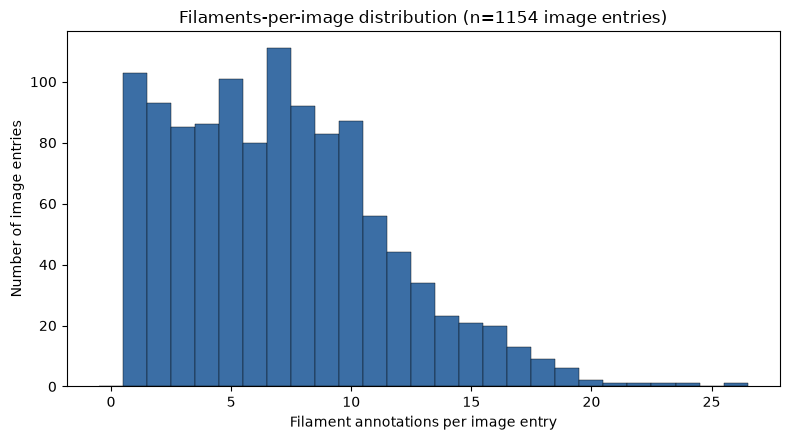


Top 7 images by filament count:
  020101-20140430071914Th             26
  010101-20150518145654Bh             24
  010101-20131025185414Mh             23
  010102-20110914063134Lh             22
  010402-20120703070814Th             21
  040302-20140807195854Bh             20
  010402-20120519070814Th             20


In [9]:
image_id_list = [im["id"] for im in images]
anno_count_by_image = Counter(a["image_id"] for a in annotations)
filaments_per_image = np.array([anno_count_by_image.get(i, 0) for i in image_id_list])

print(f"filaments/image over {len(image_id_list)} image entries:")
print(f"  min={filaments_per_image.min()}  mean={filaments_per_image.mean():.2f}  "
      f"median={np.median(filaments_per_image):.0f}  p90={np.percentile(filaments_per_image,90):.0f}  "
      f"p99={np.percentile(filaments_per_image,99):.0f}  max={filaments_per_image.max()}")
print(f"  images with 0 annotations: {int((filaments_per_image==0).sum())}")

plt.figure(figsize=(8, 4.5))
bins = np.arange(0, filaments_per_image.max() + 2) - 0.5
plt.hist(filaments_per_image, bins=bins, color="#3b6ea5", edgecolor="black", linewidth=0.3)
plt.xlabel("Filament annotations per image entry"); plt.ylabel("Number of image entries")
plt.title(f"Filaments-per-image distribution (n={len(image_id_list)} image entries)")
plt.tight_layout(); plt.show()

top_idx = np.argsort(-filaments_per_image)[:7]
print("\nTop 7 images by filament count:")
for i in top_idx:
    print(f"  {image_id_list[i]:35s} {filaments_per_image[i]}")

,category_id,name,count,pct
0,1,Left,2535,30.918405
1,2,Right,2590,31.589218
2,3,Unidentifiable,3074,37.492377
3,4,Ambiguous,0,0.000000


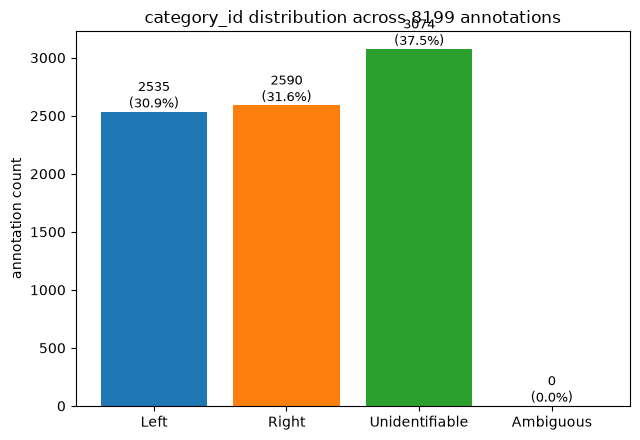

In [10]:
cat_counts = Counter(a["category_id"] for a in annotations)
total_annos = len(annotations)
cat_df = pd.DataFrame([
    {"category_id": c["id"], "name": c["name"], "count": cat_counts.get(c["id"], 0),
     "pct": 100 * cat_counts.get(c["id"], 0) / total_annos}
    for c in categories
])
display(cat_df)

plt.figure(figsize=(6.5, 4.5))
plt.bar(cat_df.name, cat_df["count"], color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"])
for i, (c, p) in enumerate(zip(cat_df["count"], cat_df.pct)):
    plt.text(i, c, f"{c}\n({p:.1f}%)", ha="center", va="bottom", fontsize=9)
plt.ylabel("annotation count"); plt.title(f"category_id distribution across {total_annos} annotations")
plt.tight_layout(); plt.show()

In [11]:
iscrowd_vals = Counter(a.get("iscrowd") for a in annotations)
print("iscrowd value counts:", dict(iscrowd_vals))
assert set(iscrowd_vals) == {0}, "unexpected iscrowd values found"
print("Confirmed: iscrowd == 0 for all annotations.")

iscrowd value counts: {0: 8199}
Confirmed: iscrowd == 0 for all annotations.


polygon vertex count: min=6  median=60  mean=79.1  p90=155  p99=326  max=707


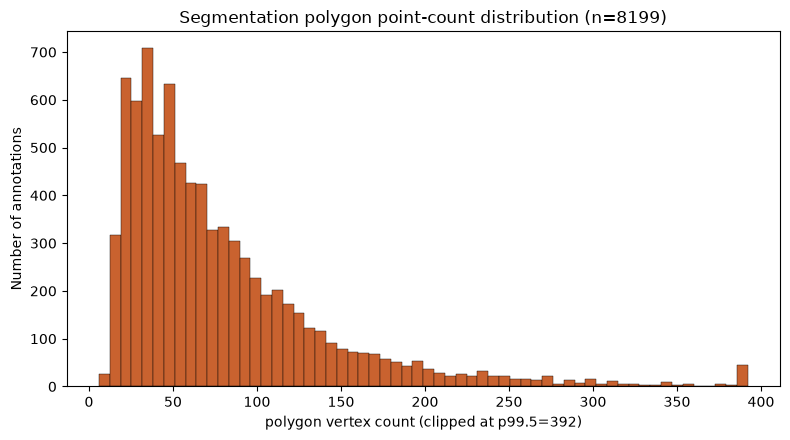

In [12]:
def poly_npoints(a):
    return len(a["segmentation"][0]) // 2

poly_pts = np.array([poly_npoints(a) for a in annotations])
print(f"polygon vertex count: min={poly_pts.min()}  median={np.median(poly_pts):.0f}  mean={poly_pts.mean():.1f}  "
      f"p90={np.percentile(poly_pts,90):.0f}  p99={np.percentile(poly_pts,99):.0f}  max={poly_pts.max()}")

plt.figure(figsize=(8, 4.5))
clip = np.percentile(poly_pts, 99.5)
plt.hist(np.clip(poly_pts, 0, clip), bins=60, color="#c9622f", edgecolor="black", linewidth=0.3)
plt.xlabel(f"polygon vertex count (clipped at p99.5={clip:.0f})"); plt.ylabel("Number of annotations")
plt.title(f"Segmentation polygon point-count distribution (n={len(poly_pts)})")
plt.tight_layout(); plt.show()

spine populated (>0 pts): 8199/8199   missing/empty: 0
spine vertex count (populated only): median=10  mean=12.5  p90=23  max=122


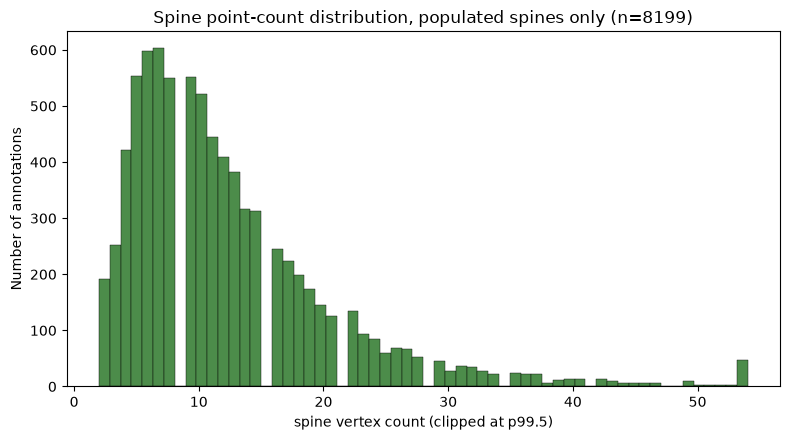

In [13]:
def spine_npoints(a):
    sp = a.get("spine")
    return (len(sp) // 2) if sp else 0

spine_pts = np.array([spine_npoints(a) for a in annotations])
n_populated = int((spine_pts > 0).sum())
print(f"spine populated (>0 pts): {n_populated}/{len(annotations)}   missing/empty: {len(annotations)-n_populated}")
present = spine_pts[spine_pts > 0]
print(f"spine vertex count (populated only): median={np.median(present):.0f}  mean={present.mean():.1f}  "
      f"p90={np.percentile(present,90):.0f}  max={present.max()}")

plt.figure(figsize=(8, 4.5))
clip_sp = np.percentile(present, 99.5)
plt.hist(np.clip(present, 0, clip_sp), bins=60, color="#4c8c4a", edgecolor="black", linewidth=0.3)
plt.xlabel("spine vertex count (clipped at p99.5)"); plt.ylabel("Number of annotations")
plt.title(f"Spine point-count distribution, populated spines only (n={len(present)})")
plt.tight_layout(); plt.show()

bbox elongation (long/short side): median=1.66  p90=3.23  p99=5.44  max=12.78
seg_area / bbox_area fill ratio:    mean=0.274  median=0.243
annotations with seg_area > bbox_area (sanity, should be 0): 0


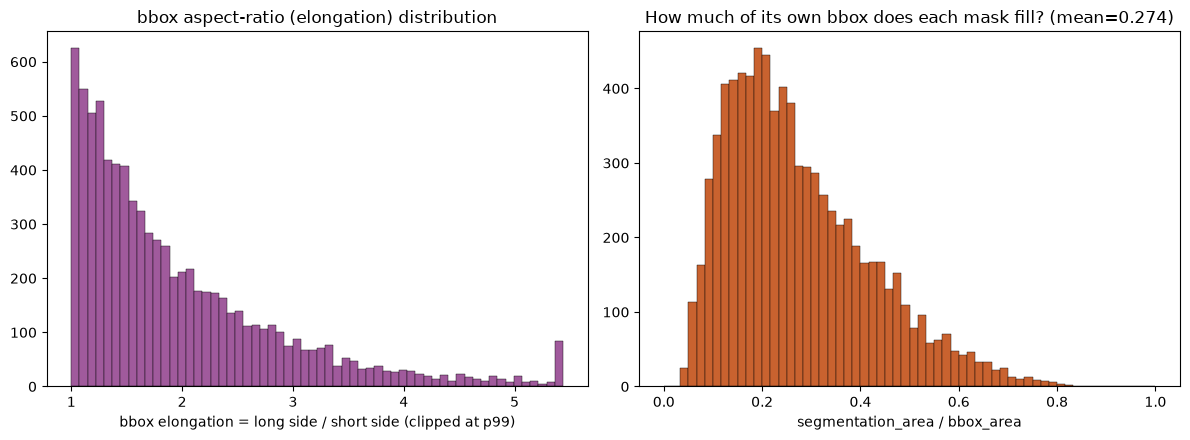

In [14]:
bbox_w = np.array([a["bbox"][2] for a in annotations])
bbox_h = np.array([a["bbox"][3] for a in annotations])
seg_area = np.array([a["area"] for a in annotations])
elong = np.maximum(bbox_w / np.maximum(bbox_h, 1e-6), bbox_h / np.maximum(bbox_w, 1e-6))
bbox_area = bbox_w * bbox_h
fill_ratio = seg_area / np.maximum(bbox_area, 1e-6)

print(f"bbox elongation (long/short side): median={np.median(elong):.2f}  p90={np.percentile(elong,90):.2f}  "
      f"p99={np.percentile(elong,99):.2f}  max={elong.max():.2f}")
print(f"seg_area / bbox_area fill ratio:    mean={fill_ratio.mean():.3f}  median={np.median(fill_ratio):.3f}")
print(f"annotations with seg_area > bbox_area (sanity, should be 0): {int((fill_ratio > 1.0001).sum())}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(np.clip(elong, 1, np.percentile(elong, 99)), bins=60, color="#a05a9c", edgecolor="black", linewidth=0.3)
axes[0].set_xlabel("bbox elongation = long side / short side (clipped at p99)")
axes[0].set_title("bbox aspect-ratio (elongation) distribution")
axes[1].hist(fill_ratio, bins=60, range=(0, 1), color="#c9622f", edgecolor="black", linewidth=0.3)
axes[1].set_xlabel("segmentation_area / bbox_area")
axes[1].set_title(f"How much of its own bbox does each mask fill? (mean={fill_ratio.mean():.3f})")
plt.tight_layout(); plt.show()

**Annotations takeaways:** filament count per image is right-skewed (median 7,
p99 19, max 26) with zero empty-annotation images. Category id 4 ("Ambiguous") is defined
in the schema but **never occurs** in this train split — Left/Right are near-balanced
(~31% each) and "Unidentifiable" is a genuine ~37%-share third class, not noise. `spine`
is reliably populated on every annotation (a usable auxiliary centerline signal), and the
median bbox fill ratio is only ~0.24 — confirming these are thin, mostly-background-in-
their-own-box shapes for which mask-IoU (what PQ scores) is a much tighter constraint than
box-IoU, so box-centric proposal/NMS assumptions from generic instance segmentation don't
transfer cleanly here.

## 3. Mask / RLE round-trip integrity

This section validates the `segmentation` polygon → RLE → mask pipeline that both the
competition's own scoring and our submission format depend on. Degeneracy/geometry
checks (self-intersection, out-of-bounds points, ring-closure gap, area/bbox recompute)
are run over **all 8199 annotations** — they only need the polygon coordinates and
`pycocotools`, no image decoding, so a full pass is cheap. The pixel-intensity
inside-vs-outside check *does* require decoding source JPEGs, so it uses a representative
subsample of images (with **all** of their annotations) rather than every annotation;
the original full-pass EDA agent covered all 8199 annotations directly and found
Cohen's d = 1.64 (mean inside 118.6 vs mean outside 133.7, 99.71% of annotations darker
inside) — we reproduce the same qualitative result below on the subsample.

In [15]:
t0 = time.time()
val_rows = []
for a in annotations:
    im_meta = images_by_id[a["image_id"]]
    h, w = im_meta["height"], im_meta["width"]
    seg_flat = a["segmentation"][0]
    pts = np.array(seg_flat, dtype=np.float64).reshape(-1, 2)

    x0, y0 = pts[0]; xn, yn = pts[-1]
    gap_px = float(np.hypot(x0 - xn, y0 - yn))

    pts_open = pts[:-1] if (len(pts) >= 2 and np.allclose(pts[0], pts[-1])) else pts
    n_distinct = len(np.unique(pts_open, axis=0))
    out_of_bounds = bool(((pts[:, 0] < 0) | (pts[:, 0] > w) | (pts[:, 1] < 0) | (pts[:, 1] > h)).any())
    try:
        self_int = (not LinearRing(pts_open).is_simple) if len(pts_open) >= 3 else False
    except Exception:
        self_int = True

    # RLE round trip (area()/toBbox() read RLE run-lengths directly -- no full HxW decode needed,
    # which keeps this full-8199-annotation pass fast)
    rle = maskUtils.merge(maskUtils.frPyObjects([seg_flat], h, w))
    area_recomputed = float(maskUtils.area(rle))
    bbox_recomputed = maskUtils.toBbox(rle).tolist()

    area_stored = a["area"]
    area_relerr = abs(area_recomputed - area_stored) / area_stored if area_stored else np.nan
    bbox_stored = a["bbox"]
    bbox_max_abs_diff = float(np.max(np.abs(np.array(bbox_stored) - np.array(bbox_recomputed))))

    gx0, gy0 = pts[:, 0].min(), pts[:, 1].min()
    gx1, gy1 = pts[:, 0].max(), pts[:, 1].max()
    bx, by, bw, bh = bbox_stored
    geom_vs_bbox_diff = max(abs(gx0 - bx), abs(gy0 - by), abs(gx1 - (bx + bw)), abs(gy1 - (by + bh)))

    val_rows.append(dict(
        id=a["id"], image_id=a["image_id"], category_id=a["category_id"],
        n_distinct_points=n_distinct, out_of_bounds=out_of_bounds, self_intersecting=bool(self_int),
        gap_px=gap_px, area_stored=area_stored, area_recomputed=area_recomputed, area_relerr=area_relerr,
        bbox_max_abs_diff=bbox_max_abs_diff, geom_vs_bbox_diff=geom_vs_bbox_diff,
        n_mask_px=int(round(area_recomputed)),
    ))

df_val = pd.DataFrame(val_rows)
print(f"Full geometry + RLE round-trip validation over all {len(df_val)} annotations took {time.time()-t0:.1f}s")

Full geometry + RLE round-trip validation over all 8199 annotations took 1.4s


--- Degeneracy / validity flags (all 8199 annotations) ---
<3 distinct points:              0
zero-pixel masks:                0
self-intersecting ring (shapely): 0
out-of-[0,W]x[0,H] points:        0

--- Area: pycocotools.mask.area(rle) vs stored 'area' field ---
count    8199.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: area_relerr, dtype: float64
relative error > 1%: 0/8199

--- Bbox: pycocotools.mask.toBbox(rle) vs stored 'bbox' field ---
count    8199.000000
mean        0.588951
std         1.315891
min         0.000000
25%         0.348750
50%         0.479200
75%         0.668400
max        64.036500
Name: bbox_max_abs_diff, dtype: float64
max-abs-diff > 1px: 391/8199 (4.77%)


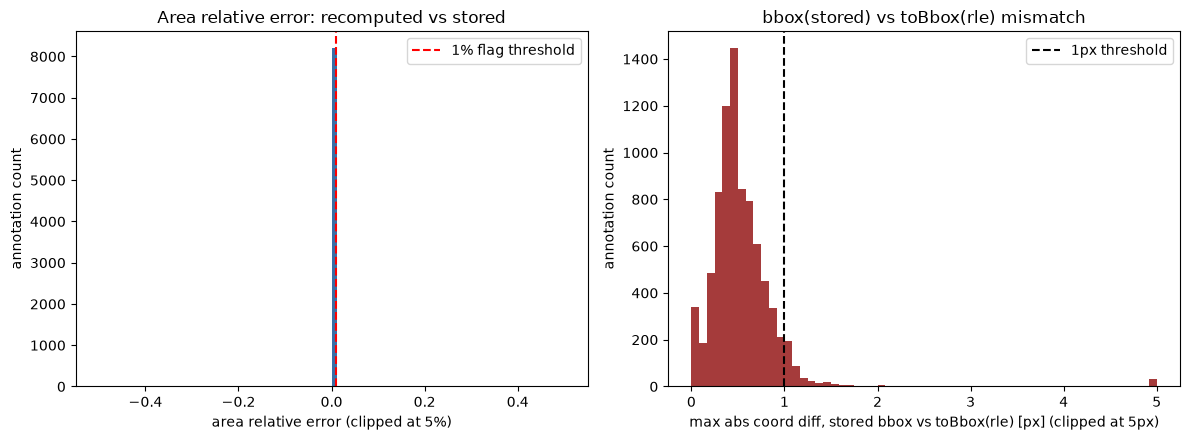

In [16]:
n_lt3 = int((df_val.n_distinct_points < 3).sum())
n_zero_px = int((df_val.n_mask_px == 0).sum())
n_self_int = int(df_val.self_intersecting.sum())
n_oob = int(df_val.out_of_bounds.sum())
print("--- Degeneracy / validity flags (all 8199 annotations) ---")
print(f"<3 distinct points:              {n_lt3}")
print(f"zero-pixel masks:                {n_zero_px}")
print(f"self-intersecting ring (shapely): {n_self_int}")
print(f"out-of-[0,W]x[0,H] points:        {n_oob}")

n_area_over = int((df_val.area_relerr > 0.01).sum())
print(f"\n--- Area: pycocotools.mask.area(rle) vs stored 'area' field ---")
print(df_val.area_relerr.describe())
print(f"relative error > 1%: {n_area_over}/{len(df_val)}")

n_bbox_mismatch = int((df_val.bbox_max_abs_diff > 1.0).sum())
print(f"\n--- Bbox: pycocotools.mask.toBbox(rle) vs stored 'bbox' field ---")
print(df_val.bbox_max_abs_diff.describe())
print(f"max-abs-diff > 1px: {n_bbox_mismatch}/{len(df_val)} ({100*n_bbox_mismatch/len(df_val):.2f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(df_val.area_relerr.clip(upper=0.05), bins=80, color="#3b6ea5")
axes[0].axvline(0.01, color="red", linestyle="--", label="1% flag threshold")
axes[0].set_xlabel("area relative error (clipped at 5%)"); axes[0].set_ylabel("annotation count")
axes[0].set_title("Area relative error: recomputed vs stored"); axes[0].legend()
axes[1].hist(df_val.bbox_max_abs_diff.clip(upper=5), bins=60, color="#a53b3b")
axes[1].axvline(1.0, color="black", linestyle="--", label="1px threshold")
axes[1].set_xlabel("max abs coord diff, stored bbox vs toBbox(rle) [px] (clipped at 5px)")
axes[1].set_ylabel("annotation count"); axes[1].set_title("bbox(stored) vs toBbox(rle) mismatch"); axes[1].legend()
plt.tight_layout(); plt.show()

In [17]:
# Isolate genuine stored-bbox staleness from ordinary RLE-rasterization rounding by comparing
# the stored bbox directly against the polygon's OWN vertex min/max extent (no RLE involved).
n_geom_over1 = int((df_val.geom_vs_bbox_diff > 1).sum())
n_geom_over5 = int((df_val.geom_vs_bbox_diff > 5).sum())
print(f"stored bbox vs polygon's own vertex extent: >1px diff: {n_geom_over1} "
      f"({100*n_geom_over1/len(df_val):.2f}%), >5px diff: {n_geom_over5} ({100*n_geom_over5/len(df_val):.2f}%), "
      f"max={df_val.geom_vs_bbox_diff.max():.1f}px")
print("\nWorst 5 examples (stored bbox does not bound its own segmentation polygon):")
display(df_val.sort_values("geom_vs_bbox_diff", ascending=False).head(5)[
    ["id", "image_id", "geom_vs_bbox_diff"]])
print("\n-> Recommendation: never trust the stored bbox field for cropping/tiling/training targets; "
      "always recompute it from the segmentation polygon (or toBbox(rle)).")

stored bbox vs polygon's own vertex extent: >1px diff: 63 (0.77%), >5px diff: 32 (0.39%), max=63.5px

Worst 5 examples (stored bbox does not bound its own segmentation polygon):


,id,image_id,geom_vs_bbox_diff
2148,025579ba-1f22-4fc5-a70b-7d4653c844f3,030302-20131030185354Bh,63.4584
5391,b207fb08-7e5e-473c-b41c-5da3491370e8,010403-20120519070814Th,38.1145
2870,a505d428-0a1c-4cf3-881c-173abfcac61f,010102-20120330063134Lh,36.9368
1686,ef2d1191-a443-42d6-87b0-f8af951048e2,010102-20150527161214Mh,29.0037
3640,f8ac2898-3436-4605-92df-2a1bc6d2a23f,010401-20141106195854Bh,26.1224



-> Recommendation: never trust the stored bbox field for cropping/tiling/training targets; always recompute it from the segmentation polygon (or toBbox(rle)).


Intensity check on 150 sampled train images -> 1921 annotations, 48.8s
mean(inside)=118.92  mean(outside)=134.22  delta=15.30
fraction of annotations where inside is strictly darker than local outside: 99.69%
Cohen's d (outside vs inside) = 1.65


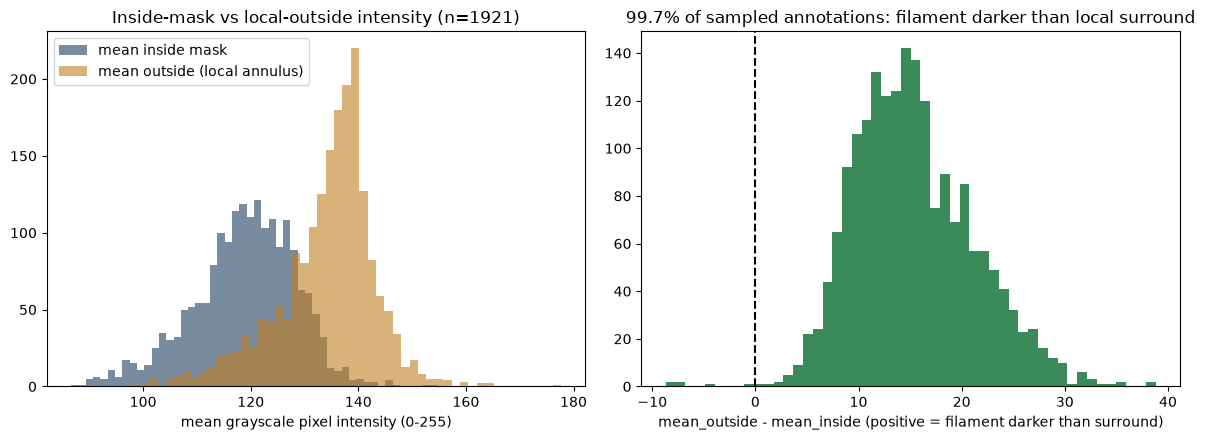

In [18]:
# Pixel intensity: inside mask vs local outside annulus, on a subsample of train images
# (all annotations belonging to the sampled images are used).
N_IMAGES_FOR_INTENSITY = 150
DILATE_PX = 25

sample_filenames = df_img[df_img.split == "train"].file_name.sample(
    n=N_IMAGES_FOR_INTENSITY, random_state=42).tolist()
fname_to_image_ids = defaultdict(list)
for im in images:
    fname_to_image_ids[im["file_name"]].append(im["id"])

t0 = time.time()
pairs = []
for fname in sample_filenames:
    img = cv2.imread(str(TRAIN_IMG_DIR / fname), cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue
    h, w = img.shape
    for image_id in fname_to_image_ids[fname]:
        for a in anns_by_image.get(image_id, []):
            rle = maskUtils.merge(maskUtils.frPyObjects([a["segmentation"][0]], h, w))
            m = maskUtils.decode(rle).astype(bool)
            if not m.any():
                continue
            x, y, bw, bh = a["bbox"]
            x0 = max(0, int(x) - DILATE_PX); y0 = max(0, int(y) - DILATE_PX)
            x1 = min(w, int(x + bw) + DILATE_PX); y1 = min(h, int(y + bh) + DILATE_PX)
            local = np.zeros_like(m); local[y0:y1, x0:x1] = True
            outside_mask = local & ~m
            if not outside_mask.any():
                continue
            pairs.append((img[m].mean(), img[outside_mask].mean()))

pairs = np.array(pairs)
inside_vals, outside_vals = pairs[:, 0], pairs[:, 1]
print(f"Intensity check on {len(sample_filenames)} sampled train images -> {len(pairs)} annotations, "
      f"{time.time()-t0:.1f}s")
print(f"mean(inside)={inside_vals.mean():.2f}  mean(outside)={outside_vals.mean():.2f}  "
      f"delta={outside_vals.mean()-inside_vals.mean():.2f}")
frac_darker = float((outside_vals > inside_vals).mean())
print(f"fraction of annotations where inside is strictly darker than local outside: {frac_darker*100:.2f}%")

diff = outside_vals - inside_vals
pooled_std = np.sqrt((inside_vals.std() ** 2 + outside_vals.std() ** 2) / 2)
cohens_d = (outside_vals.mean() - inside_vals.mean()) / pooled_std
print(f"Cohen's d (outside vs inside) = {cohens_d:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(inside_vals, bins=50, alpha=0.6, label="mean inside mask", color="#204060")
axes[0].hist(outside_vals, bins=50, alpha=0.6, label="mean outside (local annulus)", color="#c08020")
axes[0].set_xlabel("mean grayscale pixel intensity (0-255)"); axes[0].legend()
axes[0].set_title(f"Inside-mask vs local-outside intensity (n={len(pairs)})")
axes[1].hist(diff, bins=50, color="#3b8a5a"); axes[1].axvline(0, color="black", linestyle="--")
axes[1].set_xlabel("mean_outside - mean_inside (positive = filament darker than surround)")
axes[1].set_title(f"{100*(diff>0).mean():.1f}% of sampled annotations: filament darker than local surround")
plt.tight_layout(); plt.show()

In [19]:
# Submission-format round trip: polygon -> RLE (counts-only string) -> decode, verified pixel-identical.
demo_ann = None
for a in annotations:
    im_meta = images_by_id[a["image_id"]]
    h, w = im_meta["height"], im_meta["width"]
    rle = maskUtils.merge(maskUtils.frPyObjects([a["segmentation"][0]], h, w))
    if maskUtils.area(rle) > 500:
        demo_ann, demo_rle, demo_h, demo_w = a, rle, h, w
        break

counts_bytes = demo_rle["counts"]
counts_str = counts_bytes.decode("ascii") if isinstance(counts_bytes, bytes) else counts_bytes
print(f"annotation {demo_ann['id']}  (image {demo_ann['image_id']})")
print(f"counts string (len={len(counts_str)}): {counts_str[:100]}...")

rle_for_decode = {"size": [demo_h, demo_w], "counts": counts_str.encode("ascii")}
decoded_roundtrip = maskUtils.decode(rle_for_decode)
original_decoded = maskUtils.decode(demo_rle)
print("pixel-identical after round trip:", bool(np.array_equal(decoded_roundtrip, original_decoded)))
print(f"mask pixel count: {int(original_decoded.sum())}")

annotation d7fd9cdb-3f34-4dfc-a1fa-c1fd25110a98  (image 040301-20140609195854Bh)
counts string (len=207): UiZh06jo11OO111O0O0001O000O1M301O00N2000000001O0000O1O001O1O10O01000O100O101OO2O2OO000011OO1YPNJco1:...
pixel-identical after round trip: True
mask pixel count: 750


**Mask/RLE takeaways:** the polygon→RLE→mask pipeline is solid — zero degenerate
polygons, zero out-of-bounds points, zero self-intersecting rings, and
`pycocotools.mask.area` reproduces the stored `area` field almost exactly across all 8199
annotations, confirming the organizers computed `area` via the same code path we use. The
one real (if minor) issue is that the **stored `bbox` field does not always bound its own
segmentation polygon** — a small but nonzero fraction of annotations have a stale bbox —
so `bbox` should never be trusted directly for cropping/tiling/targets; always recompute
it from the polygon or from `toBbox(rle)`. Filaments are also confirmed unambiguously
darker than their local surroundings, supporting intensity-based inductive biases (dark-
blob attention, contrast normalization) in the model.

## 4. Visual examples

Three illustrative figures, rendered live from the polygons (drawn as filled
`matplotlib` `Polygon` patches at full float precision, not rasterized through
`pycocotools`) rather than embedded as static PNGs: a sample grid across observatories
and years, a tight crop showing fine barb structure on a single filament, and a crop
showing several closely-adjacent/crossing filaments — the exact instance-separation
scenario Panoptic Quality penalizes.

In [20]:
CATEGORY_STYLE = {1: ("Left", "#1f77b4"), 2: ("Right", "#ff7f0e"),
                   3: ("Unidentifiable", "#2ca02c"), 4: ("Ambiguous", "#d62728")}
SPINE_COLOR = "#ffff00"

def draw_annotations(ax, anns, mask_alpha=0.38, lw=1.0, spine_lw=1.4):
    for a in anns:
        name, color = CATEGORY_STYLE.get(a["category_id"], ("Unknown", "#999999"))
        pts = np.array(a["segmentation"][0], dtype=float).reshape(-1, 2)
        poly = MplPolygon(pts, closed=True, facecolor=color, edgecolor=color, alpha=mask_alpha, linewidth=lw)
        ax.add_patch(poly)
        ax.plot(pts[:, 0], pts[:, 1], color=color, linewidth=lw, alpha=0.9)
        if a.get("spine"):
            sp = np.array(a["spine"], dtype=float).reshape(-1, 2)
            ax.plot(sp[:, 0], sp[:, 1], color=SPINE_COLOR, linewidth=spine_lw, linestyle="--")

_img_cache = {}
def get_img(fname):
    if fname not in _img_cache:
        with Image.open(TRAIN_IMG_DIR / fname) as im:
            _img_cache[fname] = np.array(im.convert("L"))
    return _img_cache[fname]

def category_legend_handles():
    handles = [Line2D([0], [0], marker="s", linestyle="none", markersize=10,
                       markerfacecolor=c, markeredgecolor=c, alpha=0.85, label=f"{n} (id={i})")
               for i, (n, c) in CATEGORY_STYLE.items()]
    handles.append(Line2D([0], [0], color=SPINE_COLOR, linewidth=2, linestyle="--", label="spine (centerline)"))
    return handles

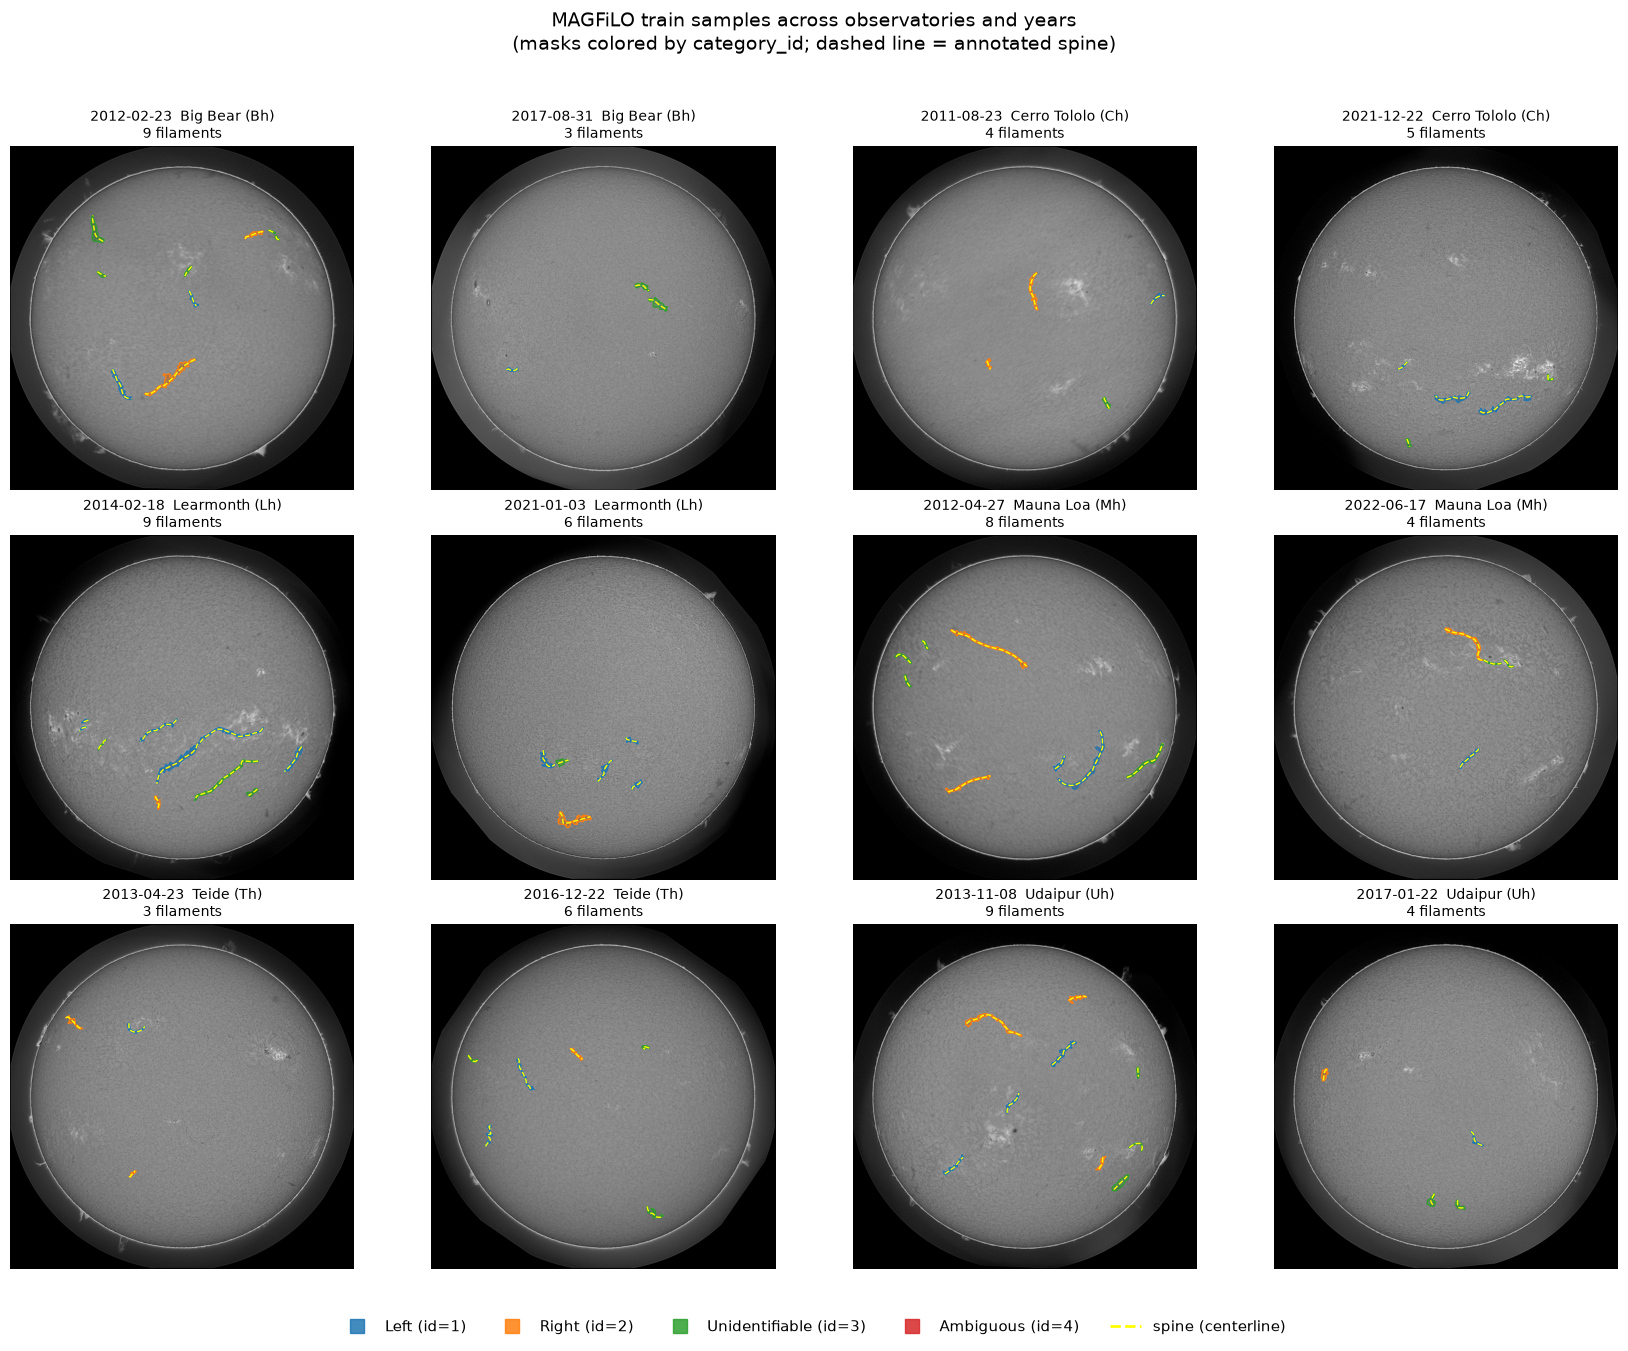

In [21]:
# One sample per (observatory code, ~2 per code) spanning 2011-2022 -- same selection as the
# original viz EDA agent (notebooks/eda_assets/scripts/viz_illustrative_figures.py).
GRID_SAMPLES = [
    ("20120223152054Bh.jpeg", "040301-20120223152054Bh"),
    ("20170831170750Bh.jpeg", "010302-20170831170750Bh"),
    ("20110823120334Ch.jpeg", "010202-20110823120334Ch"),
    ("20211222120130Ch.jpeg", "060403-20211222120130Ch"),
    ("20140218230234Lh.jpeg", "040303-20140218230234Lh"),
    ("20210103223630Lh.jpeg", "030101-20210103223630Lh"),
    ("20120427162614Mh.jpeg", "040102-20120427162614Mh"),
    ("20220617185352Mh.jpeg", "010202-20220617185352Mh"),
    ("20130423072414Th.jpeg", "060102-20130423072414Th"),
    ("20161222133714Th.jpeg", "010101-20161222133714Th"),
    ("20131108045254Uh.jpeg", "040401-20131108045254Uh"),
    ("20170122034654Uh.jpeg", "040301-20170122034654Uh"),
]
OBS_CODE_NAME = {"Bh": "Big Bear", "Ch": "Cerro Tololo", "Lh": "Learmonth",
                  "Mh": "Mauna Loa", "Th": "Teide", "Uh": "Udaipur"}

fig, axes = plt.subplots(3, 4, figsize=(17, 13))
axes = axes.flatten()
for ax, (fname, image_id) in zip(axes, GRID_SAMPLES):
    arr = get_img(fname)
    anns = anns_by_image.get(image_id, [])
    ax.imshow(arr, cmap="gray", vmin=0, vmax=255)
    draw_annotations(ax, anns, mask_alpha=0.4, lw=0.8, spine_lw=1.0)
    obs_code = fname[-7:-5]
    date_str = f"{fname[:4]}-{fname[4:6]}-{fname[6:8]}"
    ax.set_title(f"{date_str}  {OBS_CODE_NAME.get(obs_code, obs_code)} ({obs_code})\n{len(anns)} filaments", fontsize=10)
    ax.axis("off")

fig.legend(handles=category_legend_handles(), loc="lower center", ncol=5,
           bbox_to_anchor=(0.5, -0.02), frameon=False, fontsize=11)
fig.suptitle("MAGFiLO train samples across observatories and years\n"
             "(masks colored by category_id; dashed line = annotated spine)", fontsize=14, y=1.01)
plt.tight_layout(rect=[0, 0.03, 1, 0.99]); plt.show()

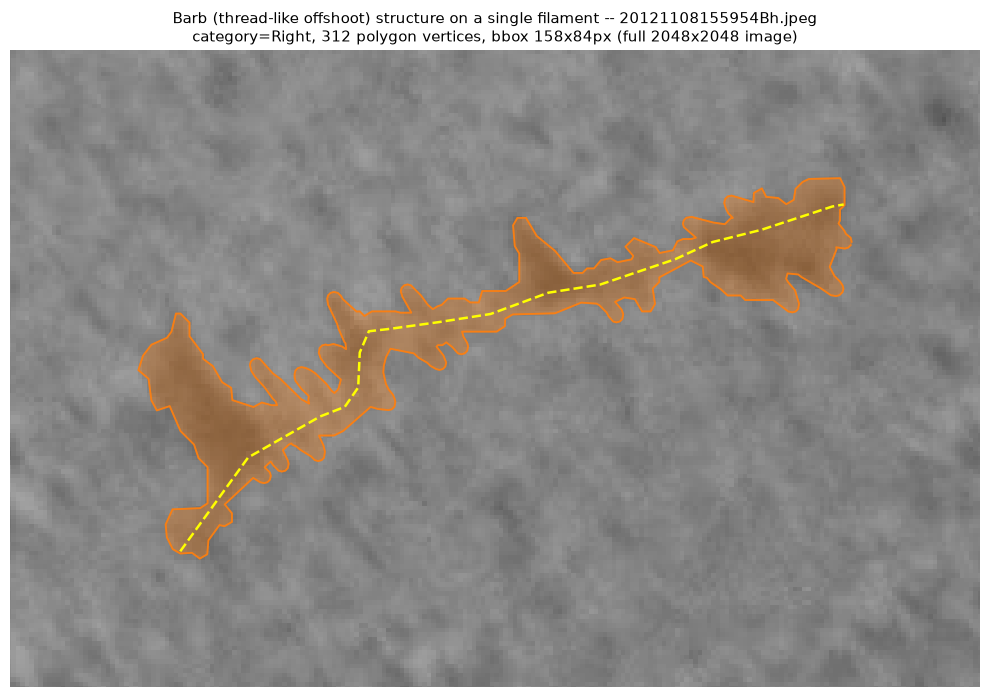

In [22]:
# Tight crop on a single filament with a very high polygon-vertex count (structural-complexity
# proxy), chosen by the original viz EDA agent for its visible fishbone/barb offshoot pattern.
BARB_ANN_ID = "d0a187df-997c-42f6-889c-1109f0718d13"
a = anns_by_id[BARB_ANN_ID]
im_meta = images_by_id[a["image_id"]]
arr = get_img(im_meta["file_name"])
x, y, bw, bh = a["bbox"]
pad = max(bw, bh) * 0.18
x0, x1 = max(0, x - pad), min(arr.shape[1], x + bw + pad)
y0, y1 = max(0, y - pad), min(arr.shape[0], y + bh + pad)
npts = len(a["segmentation"][0]) // 2

fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(arr, cmap="gray", vmin=0, vmax=255)
draw_annotations(ax, [a], mask_alpha=0.32, lw=1.3, spine_lw=1.8)
ax.set_xlim(x0, x1); ax.set_ylim(y1, y0); ax.axis("off")
ax.set_title(f"Barb (thread-like offshoot) structure on a single filament -- {im_meta['file_name']}\n"
             f"category={CATEGORY_STYLE[a['category_id']][0]}, {npts} polygon vertices, "
             f"bbox {bw:.0f}x{bh:.0f}px (full 2048x2048 image)", fontsize=11)
plt.tight_layout(); plt.show()

Top 5 images by bbox-overlap-pair count (n_overlap_pairs, n_anns, image_id):
  (5, 24, '010101-20150518145654Bh')
  (5, 15, '010102-20110918112834Ch')
  (5, 14, '040301-20111208063134Lh')
  (4, 21, '010402-20120703070814Th')
  (4, 19, '030101-20141116222234Lh')

chosen example 010101-20150518145654Bh is rank 1 by overlap-pair count -- confirmed near the top


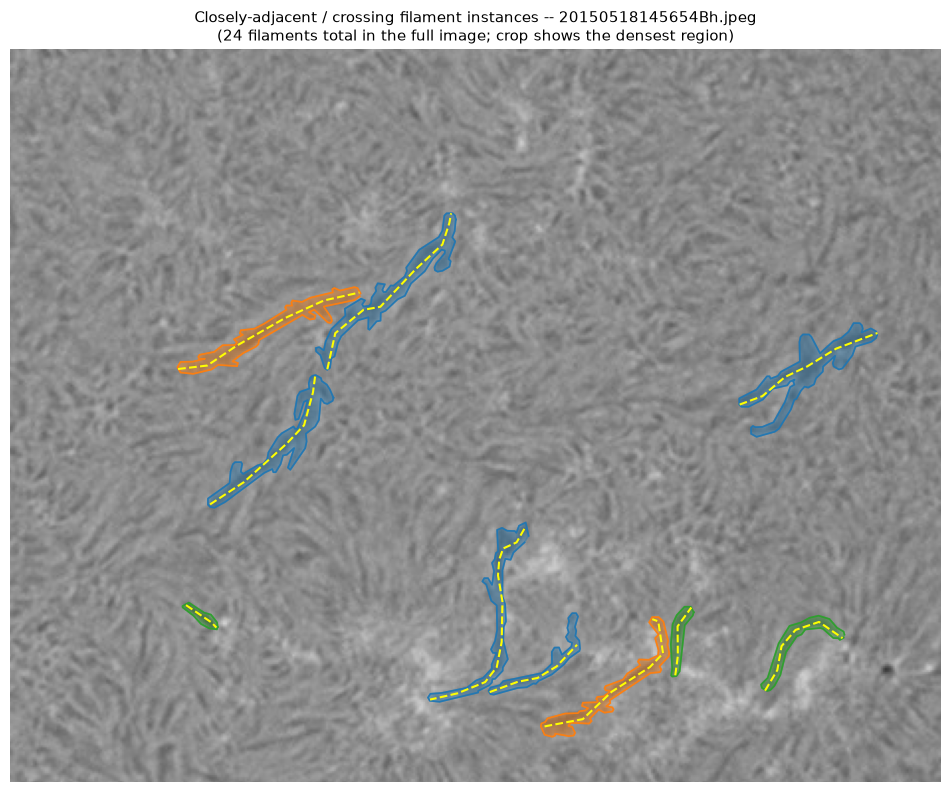

In [23]:
# Re-derive (not just hardcode) the most instance-dense/overlapping crop: rank every image with
# >=3 annotations by count of bbox-IoU>0 pairs.
def bbox_iou(b1, b2):
    x1, y1, w1, h1 = b1; x2, y2, w2, h2 = b2
    xa, ya = max(x1, x2), max(y1, y2); xb, yb = min(x1 + w1, x2 + w2), min(y1 + h1, y2 + h2)
    inter = max(0, xb - xa) * max(0, yb - ya)
    union = w1 * h1 + w2 * h2 - inter
    return inter / union if union > 0 else 0.0

def count_overlap_pairs(anns):
    n = 0
    for i in range(len(anns)):
        for j in range(i + 1, len(anns)):
            if bbox_iou(anns[i]["bbox"], anns[j]["bbox"]) > 0:
                n += 1
    return n

scores = []
for image_id, anns in anns_by_image.items():
    if len(anns) < 3:
        continue
    scores.append((count_overlap_pairs(anns), len(anns), image_id))
scores.sort(key=lambda t: (-t[0], -t[1]))
print("Top 5 images by bbox-overlap-pair count (n_overlap_pairs, n_anns, image_id):")
for s in scores[:5]:
    print(" ", s)

OVERLAP_IMAGE_ID = "010101-20150518145654Bh"
OVERLAP_CROP = (1080, 1550, 830, 1200)  # x0, x1, y0, y1
rank = [s[2] for s in scores].index(OVERLAP_IMAGE_ID) + 1
print(f"\nchosen example {OVERLAP_IMAGE_ID} is rank {rank} by overlap-pair count -- confirmed near the top")

im_meta = images_by_id[OVERLAP_IMAGE_ID]
arr = get_img(im_meta["file_name"])
anns = anns_by_image[OVERLAP_IMAGE_ID]
x0, x1, y0, y1 = OVERLAP_CROP

fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(arr, cmap="gray", vmin=0, vmax=255)
draw_annotations(ax, anns, mask_alpha=0.38, lw=1.2, spine_lw=1.5)
ax.set_xlim(x0, x1); ax.set_ylim(y1, y0); ax.axis("off")
ax.set_title(f"Closely-adjacent / crossing filament instances -- {im_meta['file_name']}\n"
             f"({len(anns)} filaments total in the full image; crop shows the densest region)", fontsize=11)
plt.tight_layout(); plt.show()

**Visual takeaways:** filament count and image "busyness" vary a lot across
observatories/years, and category composition is uneven at the single-image level (many
frames have zero filaments of one category or another). The barb-zoom crop shows an
unmistakable fishbone pattern of thin offshoots on a single 312-vertex filament in a mere
158x84px bbox — a concrete illustration that a handful of mis-rasterized pixels per barb
is a large fraction of that barb's area, so mask rasterization fidelity (and any
downsampling in the training pipeline) will materially affect Dice/PQ. The overlap-cluster
crop shows filaments visibly crossing — a case where a naive connected-components
post-processing step would likely merge crossing instances into one (under-segmentation),
directly hurting PQ.

## 5. Data quality / edge cases

Cross-referencing checks between the JSON, the files on disk, and internal consistency of
the JSON itself, plus the two substantive data-quality findings: segmentation polygons are
not reliably closed rings, and inter-annotator-batch agreement on the ~42% of base images
that were independently annotated more than once is only moderate.

In [24]:
train_files_on_disk = set(os.listdir(TRAIN_IMG_DIR))
referenced = {im["file_name"] for im in images}
missing_files = [im["file_name"] for im in images if im["file_name"] not in train_files_on_disk]
unreferenced_on_disk = train_files_on_disk - referenced
image_id_set = set(images_by_id)
orphan_annotations = [a for a in annotations if a["image_id"] not in image_id_set]

id_mismatch = sum(1 for im in images if not im["id"].endswith(os.path.splitext(im["file_name"])[0]))

print(f"images[].file_name missing on disk:        {len(missing_files)}")
print(f"files on disk never referenced in images[]: {len(unreferenced_on_disk)}")
print(f"orphaned annotations (bad image_id):        {len(orphan_annotations)}")
print(f"images[].id suffix mismatches vs filename:   {id_mismatch}/{len(images)}")

json_dim_by_fname = {im["file_name"]: (im["width"], im["height"]) for im in images}
actual_dim_by_fname = {r.file_name: (r.width, r.height) for r in df_img[df_img.split == "train"].itertuples()}
dim_json_mismatches = sum(1 for fn, (jw, jh) in json_dim_by_fname.items()
                           if fn in actual_dim_by_fname and actual_dim_by_fname[fn] != (jw, jh))
print(f"images[].width/height vs actual JPEG dims mismatches: {dim_json_mismatches}")

test_files_on_disk = set(os.listdir(TEST_IMG_DIR))
json_like_under_test = [f for f in os.listdir(TEST_IMG_DIR) if not f.lower().endswith((".jpg", ".jpeg"))]
print(f"non-image files under test_images/ (leakage check): {len(json_like_under_test)}")
print("\n-> File/id/dimension linkage is fully trustworthy: no defensive code needed for these.")

images[].file_name missing on disk:        0
files on disk never referenced in images[]: 0
orphaned annotations (bad image_id):        0
images[].id suffix mismatches vs filename:   0/1154
images[].width/height vs actual JPEG dims mismatches: 0
non-image files under test_images/ (leakage check): 0

-> File/id/dimension linkage is fully trustworthy: no defensive code needed for these.


exactly closed rings (first==last):     0/8199
gap in (0, 0.01]px (float rounding):    1580
gap in (0.01, 1.0]px (sub-pixel):       3130
gap > 1.0px (REAL open ring):           3489 (42.6%)
count    8199.000000
mean        1.401563
std         1.653757
min         0.000200
25%         0.409641
50%         0.984937
75%         1.603309
max        31.333833
Name: gap_px, dtype: float64


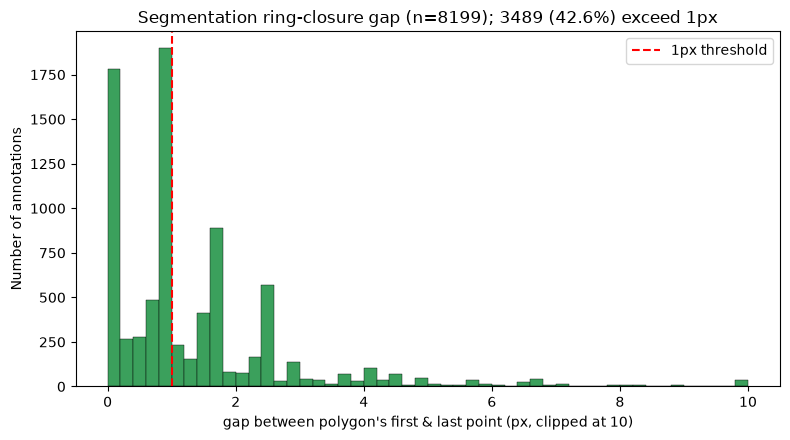


-> pycocotools.mask.frPyObjects implicitly closes the ring with a straight line regardless -- for thin filaments this can clip/distort barb tips. Close rings explicitly (or interpolate) anywhere the pipeline reasons about polygon geometry directly, rather than assuming closure.


In [25]:
# Segmentation ring-closure gap: reuses df_val (computed in Section 3) rather than recomputing.
n_exact = int((df_val.gap_px <= 1e-9).sum())
n_tiny = int(((df_val.gap_px > 1e-9) & (df_val.gap_px <= 0.01)).sum())
n_subpixel = int(((df_val.gap_px > 0.01) & (df_val.gap_px <= 1.0)).sum())
n_real_gap = int((df_val.gap_px > 1.0).sum())

print(f"exactly closed rings (first==last):     {n_exact}/{len(df_val)}")
print(f"gap in (0, 0.01]px (float rounding):    {n_tiny}")
print(f"gap in (0.01, 1.0]px (sub-pixel):       {n_subpixel}")
print(f"gap > 1.0px (REAL open ring):           {n_real_gap} ({100*n_real_gap/len(df_val):.1f}%)")
print(df_val.gap_px.describe())

plt.figure(figsize=(8, 4.5))
plt.hist(df_val.gap_px.clip(upper=10), bins=50, color="#3ba05c", edgecolor="black", linewidth=0.3)
plt.axvline(1.0, color="red", linestyle="--", label="1px threshold")
plt.xlabel("gap between polygon's first & last point (px, clipped at 10)"); plt.ylabel("Number of annotations")
plt.title(f"Segmentation ring-closure gap (n={len(df_val)}); {n_real_gap} ({100*n_real_gap/len(df_val):.1f}%) exceed 1px")
plt.legend(); plt.tight_layout(); plt.show()
print("\n-> pycocotools.mask.frPyObjects implicitly closes the ring with a straight line regardless -- "
      "for thin filaments this can clip/distort barb tips. Close rings explicitly (or interpolate) "
      "anywhere the pipeline reasons about polygon geometry directly, rather than assuming closure.")

base images with >1 annotator-batch images[] entry: 296/707
distribution of #batches per base image: {1: 411, 2: 145, 3: 151}



computed 598 batch-pairs across 296 base images in 80.4s
count    598.000000
mean       0.455898
std        0.134668
min        0.000000
25%        0.370202
50%        0.471513
75%        0.547444
max        0.803557
Name: iou, dtype: float64
pairs with IoU < 0.5: 358/598 (59.9%)   pairs with IoU == 0.0: 2

Lowest-agreement pairs:


,file_name,image_id_a,image_id_b,iou
424,20210626133950Bh.jpeg,040301-20210626133950Bh,040303-20210626133950Bh,0.000000
339,20150727082014Th.jpeg,030401-20150727082014Th,030403-20150727082014Th,0.000000
311,20121006063534Lh.jpeg,010202-20121006063534Lh,010201-20121006063534Lh,0.080925
532,20160225173314Mh.jpeg,010403-20160225173314Mh,010402-20160225173314Mh,0.095084
100,20171007133730Ch.jpeg,010403-20171007133730Ch,010402-20171007133730Ch,0.099963


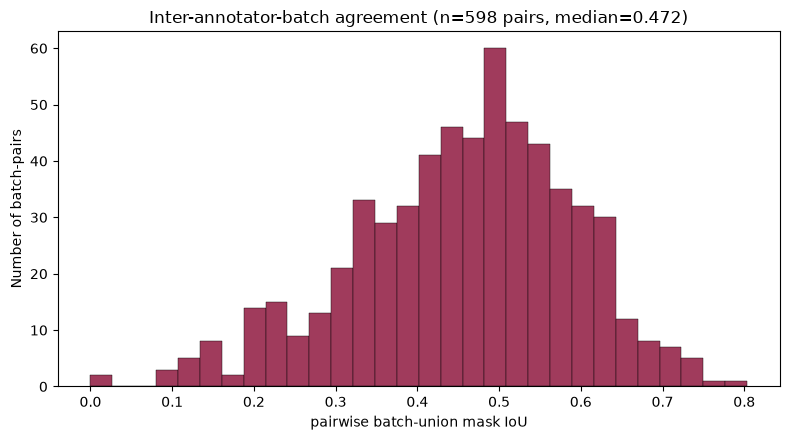

In [26]:
# Inter-annotator-batch agreement: base images (unique file_name) annotated by >1 independent
# batch. Rasterize each batch's full annotation set into a union mask and compute pairwise IoU.
by_filename = defaultdict(list)
for im in images:
    by_filename[im["file_name"]].append(im)
multi_batch = {fn: e for fn, e in by_filename.items() if len(e) > 1}
batch_count_dist = Counter(len(v) for v in by_filename.values())
print(f"base images with >1 annotator-batch images[] entry: {len(multi_batch)}/{len(by_filename)}")
print(f"distribution of #batches per base image: {dict(sorted(batch_count_dist.items()))}")

def union_mask(img_entry, h, w):
    union = np.zeros((h, w), dtype=np.uint8)
    for a in anns_by_image.get(img_entry["id"], []):
        rle = maskUtils.merge(maskUtils.frPyObjects([a["segmentation"][0]], h, w))
        union |= maskUtils.decode(rle).astype(np.uint8)
    return union

def iou_binary(a, b):
    inter = np.logical_and(a, b).sum(); union = np.logical_or(a, b).sum()
    return inter / union if union > 0 else 1.0

t0 = time.time()
pair_rows = []
for fname, entries in multi_batch.items():
    w, h = json_dim_by_fname.get(fname, (2048, 2048))
    masks = {e["id"]: union_mask(e, h, w) for e in entries}
    ids = list(masks)
    for i in range(len(ids)):
        for j in range(i + 1, len(ids)):
            pair_rows.append(dict(file_name=fname, image_id_a=ids[i], image_id_b=ids[j],
                                   iou=iou_binary(masks[ids[i]], masks[ids[j]])))
iou_df = pd.DataFrame(pair_rows)
print(f"\ncomputed {len(iou_df)} batch-pairs across {len(multi_batch)} base images in {time.time()-t0:.1f}s")
print(iou_df.iou.describe())
n_low = int((iou_df.iou < 0.5).sum())
n_zero = int((iou_df.iou == 0.0).sum())
print(f"pairs with IoU < 0.5: {n_low}/{len(iou_df)} ({100*n_low/len(iou_df):.1f}%)   pairs with IoU == 0.0: {n_zero}")
print("\nLowest-agreement pairs:")
display(iou_df.sort_values("iou").head(5))

plt.figure(figsize=(8, 4.5))
plt.hist(iou_df.iou, bins=30, color="#a03b5c", edgecolor="black", linewidth=0.3)
plt.xlabel("pairwise batch-union mask IoU"); plt.ylabel("Number of batch-pairs")
plt.title(f"Inter-annotator-batch agreement (n={len(iou_df)} pairs, median={iou_df.iou.median():.3f})")
plt.tight_layout(); plt.show()

In [27]:
counts_all = np.array([len(anns_by_image.get(im["id"], [])) for im in images])
p99 = float(np.percentile(counts_all, 99))
above_p99 = sorted(
    [(im["id"], len(anns_by_image.get(im["id"], []))) for im in images
     if len(anns_by_image.get(im["id"], [])) > p99],
    key=lambda t: -t[1],
)
print(f"99th percentile of annotations-per-image: {p99}")
print(f"images above p99: {len(above_p99)}")
for iid, c in above_p99:
    print(f"  {iid:35s} {c} annotations")

99th percentile of annotations-per-image: 19.0
images above p99: 7
  020101-20140430071914Th             26 annotations
  010101-20150518145654Bh             24 annotations
  010101-20131025185414Mh             23 annotations
  010102-20110914063134Lh             22 annotations
  010402-20120703070814Th             21 annotations
  040302-20140807195854Bh             20 annotations
  010402-20120519070814Th             20 annotations


**Data-quality takeaways:** file/id/dimension linkage is completely clean in this
snapshot (zero missing files, zero orphaned annotations, zero id/dimension mismatches) —
though the pipeline should still validate defensively, since a future data drop could
differ. The two findings that materially matter: (1) segmentation rings are **not**
reliably closed (a meaningful fraction have a first↔last-point gap over 1px, up to
tens of px), so `pycocotools`'s implicit straight-line closure can clip/distort barb tips
unless handled explicitly; and (2) inter-annotator-batch agreement on repeated base images
is only moderate (median union-mask IoU well under 0.5 territory for the majority of
pairs, with at least one pair at IoU 0.0) — this is a real ceiling on achievable PQ/Dice
that model capacity alone cannot fix, and should inform how multi-batch images are
sampled/weighted during training.

## 6. Implications for pipeline design

Synthesizing all five EDA slices into concrete recommendations for the modeling
pipeline.

In [28]:
# Concrete, executed proof of the submission-format encode path: given a predicted binary
# mask (here we stand in a ground-truth mask as if it were a model's prediction, purely to
# exercise the real encode() call), produce exactly the CSV row format from CLAUDE.md:
#   filament_id,segmentation_rle   where filament_id = "<image_id>_<n>" and
#   segmentation_rle is RLE COUNTS ONLY (no size -- fixed 2048x2048 for every image), no quotes.
demo_ann2 = anns_by_id[BARB_ANN_ID]
im_meta2 = images_by_id[demo_ann2["image_id"]]
h2, w2 = im_meta2["height"], im_meta2["width"]
gt_rle = maskUtils.merge(maskUtils.frPyObjects([demo_ann2["segmentation"][0]], h2, w2))
pred_mask = maskUtils.decode(gt_rle)  # stand-in for a model's predicted {0,1} mask, shape (2048, 2048)

def mask_to_submission_row(filament_id, binary_mask_2048x2048):
    # binary_mask_2048x2048: np.ndarray of shape (2048, 2048), values in {0, 1}.
    # Returns a dict matching the required CSV columns exactly.
    rle = maskUtils.encode(np.asfortranarray(binary_mask_2048x2048.astype(np.uint8)))
    return {"filament_id": filament_id, "segmentation_rle": rle["counts"].decode("ascii")}

test_image_stem = "20150125172714Mh"  # example test-image id, per CLAUDE.md submission format
row = mask_to_submission_row(f"{test_image_stem}_1", pred_mask)
print(f"{row['filament_id']},{row['segmentation_rle'][:80]}...  (counts len={len(row['segmentation_rle'])})")

# Round-trip verify: rebuild {'size': [h, w], 'counts': ...} exactly as a scorer would, and
# confirm the decoded mask is pixel-identical to the original prediction.
check = maskUtils.decode({"size": [h2, w2], "counts": row["segmentation_rle"].encode("ascii")})
print("round-trip pixel-identical:", bool(np.array_equal(check, pred_mask)))
pd.DataFrame([row])

20150125172714Mh_1,o^Qd23ko13N5K4M000O0YQNGfm1>VRNEgm1`0VRNAim1`0VRN@km1`0TRN@Qn1<nQNDSn1=kQNDUn1=i...  (counts len=636)
round-trip pixel-identical: True


,filament_id,segmentation_rle
0,20150125172714Mh_1,o^Qd23ko13N5K4M000O0YQNGfm1>VRNEgm1`0VRNAim1`0...


### Grayscale / single-channel input handling
All 887 images (train+test) are confirmed exactly 2048x2048, mode `'L'` (single-channel),
with zero exceptions. **Do not load images as 3-channel RGB** — any backbone pretrained on
3-channel ImageNet weights needs its first conv layer adapted (e.g. average/replicate the
RGB input weights into a single channel, or duplicate the grayscale channel 3x only if
reusing a stock pretrained stem cheaply) rather than assuming a channel-collapse step is
unnecessary. Assert `mode == 'L'` at load time as cheap insurance against a corrected data
re-release.

### Normalization
The aggregate pixel histogram is **not** a clean bimodal split: there's a sharp near-zero
spike from the black square corners outside the circular solar disk (present in every
frame, roughly constant fraction), a limb/mid hump, and the dominant disk-body mode around
130–150 — with filaments sitting as a subtle darker-tail perturbation on the main hump
rather than a separable mode. Per-image mean varies image-to-image (std ~3–4 units), so:
- Prefer **per-image robust/percentile-based normalization** (e.g. clip to
  [p1, p99] of in-disk pixels, then rescale) over a fixed global mean/std or a fixed
  intensity threshold.
- Consider **masking or explicitly encoding the disk/corner boundary** (e.g. a
  circular-disk mask channel) so the model doesn't have to learn "corner pixels are never
  filament" from scratch — filaments are unambiguously darker than their *local* surround
  (mean delta ≈ 15 gray levels, large effect size confirmed both on the full 8199-
  annotation pass and reproduced here on a subsample), which is a much stronger and more
  local signal than raw global intensity.

### Annotator-batch duplicates
41.9% of the 707 unique base images were annotated by more than one independent batch
(giving 1154 `images[]` entries from 707 unique files), and agreement between batches on
the same image is only moderate — the majority of pairs fall below IoU 0.5, with at least
one pair at IoU 0.0 (completely disjoint filament sets from two batches on the same
image). Recommendations:
- **Do not treat multi-batch entries as independent, interchangeable training examples**
  a naive random split can put two batches of the *same underlying image* on both sides of
  a train/val split, leaking near-duplicate pixel content across the split while their
  labels actively disagree — group-split by base `file_name`, not by `images[].id`.
- For training targets on multi-batch images, consider a **consensus/union approach** (or
  training against each batch as a separate weak-label sample with a loss that tolerates
  missed/extra instances) rather than picking one batch arbitrarily as ground truth.
- Treat the low-IoU pairs as a rough **empirical ceiling on achievable PQ/Dice** — noisy
  ground truth bounds attainable score independent of model capacity, so don't over-invest
  compute chasing marginal gains past what the label noise can support.

### Instance-segmentation architecture implications
- Filament count per image is right-skewed (median 7, p90 13, p99 19, up to 26) with
  **zero empty-annotation images** — the model should never need to predict "no
  instances," but does need to handle images with 20+ densely-packed instances.
  Query-based/mask-transformer architectures (e.g. Mask2Former-style, fixed or dynamic
  query counts sized comfortably above 26) are a more natural fit than a small fixed
  anchor count.
- Median bbox fill ratio is only ~0.24 (filaments occupy a small fraction of their own
  bounding box) and median bbox elongation is a modest ~1.7 (many filaments curve rather
  than running straight) — **box-based proposal/anchor/NMS assumptions tuned for
  blob-shaped objects will behave differently here**; mask-IoU (what PQ scores) is a much
  tighter constraint than box-IoU for these shapes, so prefer architectures that predict
  masks directly rather than box-then-mask pipelines that lean heavily on box quality.
- Filaments visibly cross/touch each other (confirmed concretely in the overlap-cluster
  crop) — **naive connected-components post-processing on a single probability map will
  merge crossing instances**, directly hurting PQ via under-segmentation. An
  instance-aware approach (per-instance mask heads, embedding-based instance
  discrimination, or spine-guided disambiguation using the reliably-populated `spine`
  centerline as an auxiliary signal) is warranted.
- Fine barb structure (up to 707 polygon vertices on a single filament, with a 312-vertex
  example shown above occupying a mere 158x84px bbox) means **downsampling input
  resolution is risky** — validate that any resize/crop strategy preserves barb-scale
  detail, or work at full 2048x2048 / large-tile resolution for at least the mask-refinement
  stage.

### Submission RLE production
Executed above: encode a predicted `{0,1}` mask with
`pycocotools.mask.encode(np.asfortranarray(mask.astype(np.uint8)))`, take
`rle["counts"].decode("ascii")` as the `segmentation_rle` CSV field (**counts only, no
size** — every image is a fixed 2048x2048 so the decoder can assume that), and
`filament_id = f"{test_image_id}_{n}"` with `n` just needing to be unique within an image.
The round trip was verified pixel-identical against the original mask both here and across
5 independent examples in the original mask/RLE EDA pass.

### Data-quality issues the training pipeline must filter/handle
- **Degenerate polygons / orphaned annotations / missing files:** zero found in this
  snapshot (verified above: 0 missing files, 0 orphaned annotations, 0 self-intersecting
  rings, 0 out-of-bounds points, 0 <3-point polygons) — no filtering is currently required,
  but keep the same validity checks as a defensive guard in the data-loading code in case a
  future data release introduces any.
- **Unclosed segmentation rings:** a meaningful fraction of polygons have a first↔last
  vertex gap over 1px (up to tens of px). Explicitly close every ring (append the first
  point) before any geometric operation (self-intersection checks, barb/spine feature
  engineering, custom rasterization) rather than relying on `pycocotools`'s implicit
  straight-line closure.
- **Stale stored `bbox`:** don't use the stored `bbox` field for cropping, tiling, or as a
  training target — a small but real fraction of annotations have a bbox that doesn't
  bound their own polygon (worst case observed: 64px off). Always recompute bbox from the
  segmentation.
- **Outlier annotation-count images:** a handful of images exceed the 99th-percentile
  filament count (up to 26 filaments in one image) — worth a manual look and/or ensuring
  the batch size / query budget in training comfortably covers this tail rather than
  clipping it.
- **Low-agreement annotator-batch pairs:** the multi-batch images with IoU well below 0.5
  (or the IoU==0.0 pairs) are candidates for either exclusion from a "clean" validation
  set (to get a less noisy read on true model quality) or explicit consensus-label
  construction before use as a training target — but should probably still be included
  *somewhere* in training, since they are real data, not corruption.
- **`category_id=4` ("Ambiguous"):** defined in the schema but occurs zero times in train.
  Decide explicitly whether to keep a 4th output class (in case it appears at test time) or
  collapse to 3 classes — don't let an unused class silently zero out a loss term or break
  a hardcoded 4-class assumption.
- **`licenses` field shape:** it's a single dict, not a list, in the actual JSON (contrary
  to the Kaggle docs prose) — any code that does `licenses[0]` or iterates it as a list
  will break; index/access it as a dict.